In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
results_df = pd.read_csv('full_results_20260319_010539.csv')

In [4]:
mae_cols = [col for col in results_df.columns if 'MAE' in col]
smape_cols = [col for col in results_df.columns if 'SMAPE' in col]

print('Средние MAE по методам (от лучшего к худшему):')
mae_means = results_df[mae_cols].mean().sort_values()
for method, value in mae_means.items():
    print(f'{method}: {value:.4f}')

Средние MAE по методам (от лучшего к худшему):
catboost_diff_MAE: 146.8816
baseline_naive_MAE: 148.5194
baseline_snaive_MAE: 148.5194
baseline_theta_MAE: 155.1084
catboost_raw_MAE: 198.6568
catboost_log_MAE: 249.7446
catboost_boxcox_MAE: 348.8296
baseline_ets_MAE: 468194.3866


In [5]:
print('Средние SMAPE по методам (от лучшего к худшему):')
smape_means = results_df[smape_cols].mean().sort_values()
for method, value in smape_means.items():
    print(f'{method}: {value:.4f}')

Средние SMAPE по методам (от лучшего к худшему):
catboost_diff_SMAPE: 3.2253
baseline_naive_SMAPE: 3.2377
baseline_snaive_SMAPE: 3.2377
baseline_theta_SMAPE: 3.3387
baseline_ets_SMAPE: 4.3592
catboost_raw_SMAPE: 4.6378
catboost_log_SMAPE: 5.4947
catboost_boxcox_SMAPE: 7.5072


In [6]:
if 'feature_cluster' in results_df.columns:
    print('Средний SMAPE по кластерам (feature clustering):')
    cluster_smape = results_df.groupby('feature_cluster')[smape_cols].mean()
    print(cluster_smape)

Средний SMAPE по кластерам (feature clustering):
                 baseline_naive_SMAPE  baseline_snaive_SMAPE  \
feature_cluster                                                
0                            5.179015               5.179015   
1                            2.196520               2.196520   
2                            3.367562               3.367562   
3                            1.503759               1.503759   

                 baseline_theta_SMAPE  baseline_ets_SMAPE  catboost_raw_SMAPE  \
feature_cluster                                                                 
0                            5.207586            6.043531            7.573186   
1                            2.209456            2.267936            2.702827   
2                            3.379218            5.158811            4.992808   
3                           18.791453           12.386646           10.012638   

                 catboost_log_SMAPE  catboost_boxcox_SMAPE  \
feature_cluster  

In [7]:
print('Топ-5 методов по среднему MAE:')
print(mae_means.head())

Топ-5 методов по среднему MAE:
catboost_diff_MAE      146.881597
baseline_naive_MAE     148.519365
baseline_snaive_MAE    148.519365
baseline_theta_MAE     155.108391
catboost_raw_MAE       198.656811
dtype: float64


In [7]:
print('Топ-5 методов по среднему SMAPE:')
print(smape_means.head())

Топ-5 методов по среднему SMAPE:
catboost_diff_SMAPE      3.225329
baseline_naive_SMAPE     3.237662
baseline_snaive_SMAPE    3.237662
baseline_theta_SMAPE     3.338664
baseline_ets_SMAPE       4.359215
dtype: float64


In [8]:
print('Распределение рядов по кластерам:')
if 'feature_cluster' in results_df.columns:
    print(results_df['feature_cluster'].value_counts().sort_index())

Распределение рядов по кластерам:
feature_cluster
0     30
1     67
2    102
3      1
Name: count, dtype: int64


In [8]:
print('Количество NaN значений по столбцам:')
nan_counts = results_df.isnull().sum()
for col, count in nan_counts.items():
    if count > 0:
        print(f'{col}: {count}')
if nan_counts.sum() == 0:
    print('NaN значений нет')

Количество NaN значений по столбцам:
catboost_boxcox_MAE: 37
catboost_boxcox_RMSE: 37
catboost_boxcox_SMAPE: 37
catboost_boxcox_MASE: 37


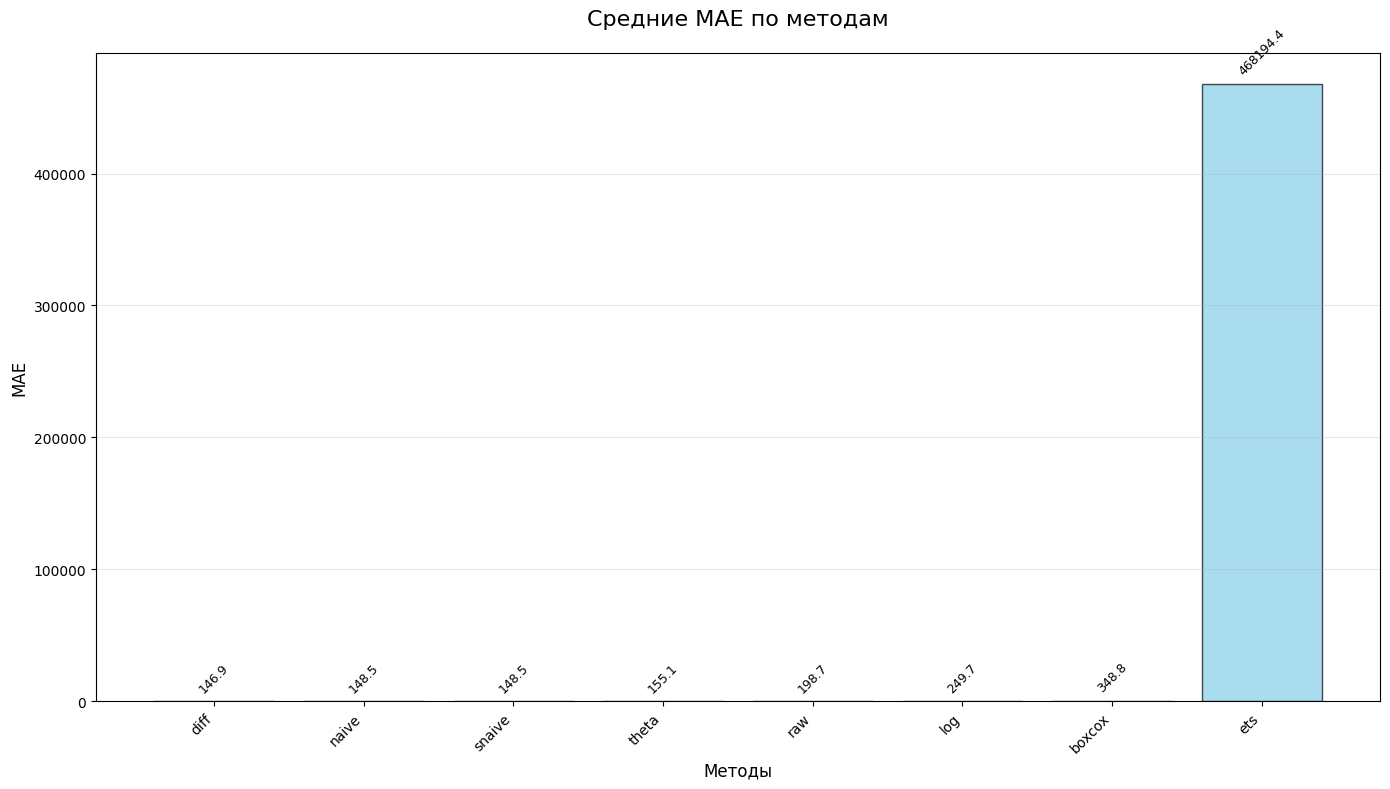

In [10]:
plt.figure(figsize=(14, 8))
bars = plt.bar(range(len(mae_means)), mae_means.values, color='skyblue', edgecolor='black', alpha=0.7)

for i, (method, value) in enumerate(mae_means.items()):
    plt.text(i, value + max(mae_means.values) * 0.01, f'{value:.1f}',
             ha='center', va='bottom', fontsize=9, rotation=45)

plt.title('Средние MAE по методам', fontsize=16, pad=20)
plt.xlabel('Методы', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.xticks(range(len(mae_means)), [m.replace('_MAE', '').replace('baseline_', '').replace('catboost_', '')
                                   for m in mae_means.index], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

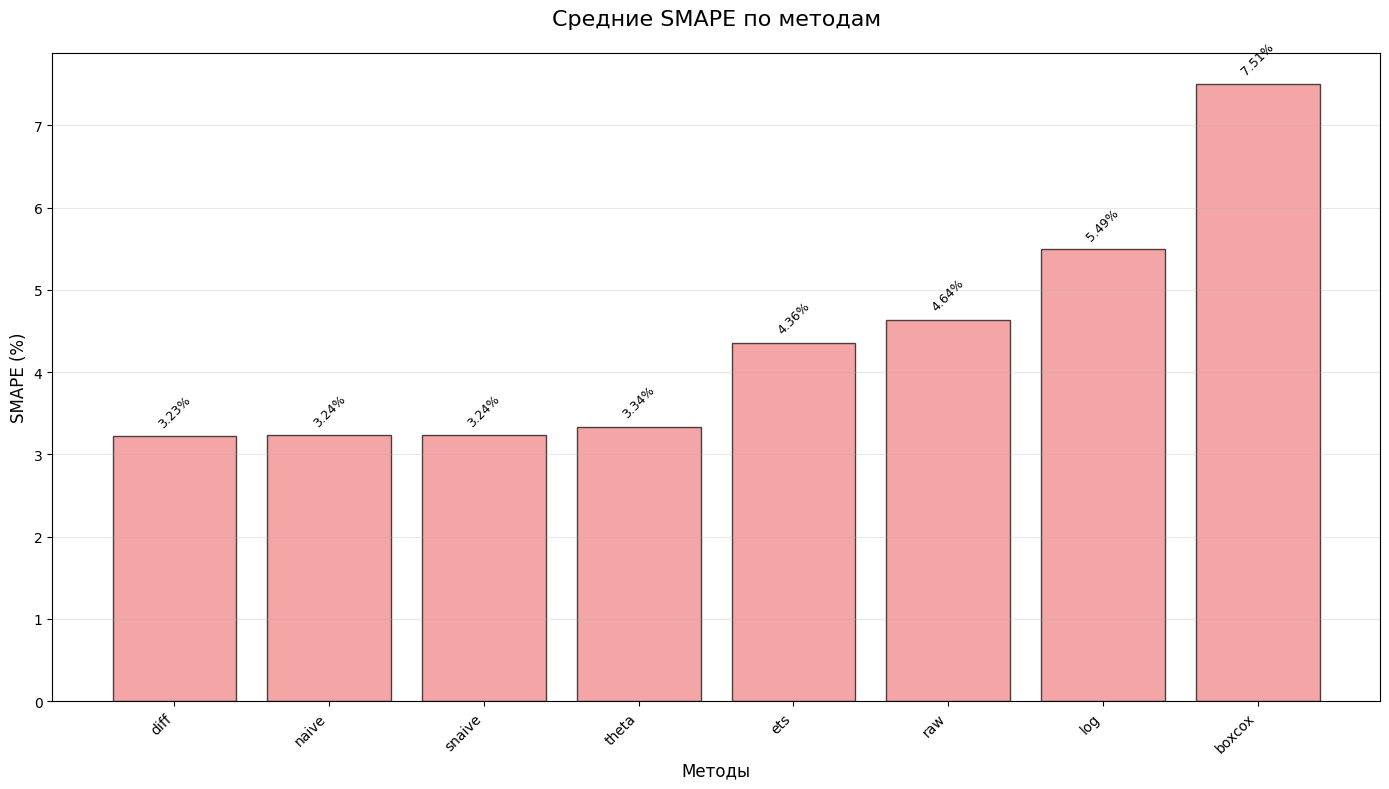

In [12]:

plt.figure(figsize=(14, 8))
bars = plt.bar(range(len(smape_means)), smape_means.values, color='lightcoral', edgecolor='black', alpha=0.7)


for i, (method, value) in enumerate(smape_means.items()):
    plt.text(i, value + max(smape_means.values) * 0.01, f'{value:.2f}%',
             ha='center', va='bottom', fontsize=9, rotation=45)

plt.title('Средние SMAPE по методам', fontsize=16, pad=20)
plt.xlabel('Методы', fontsize=12)
plt.ylabel('SMAPE (%)', fontsize=12)
plt.xticks(range(len(smape_means)), [m.replace('_SMAPE', '').replace('baseline_', '').replace('catboost_', '')
                                   for m in smape_means.index], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

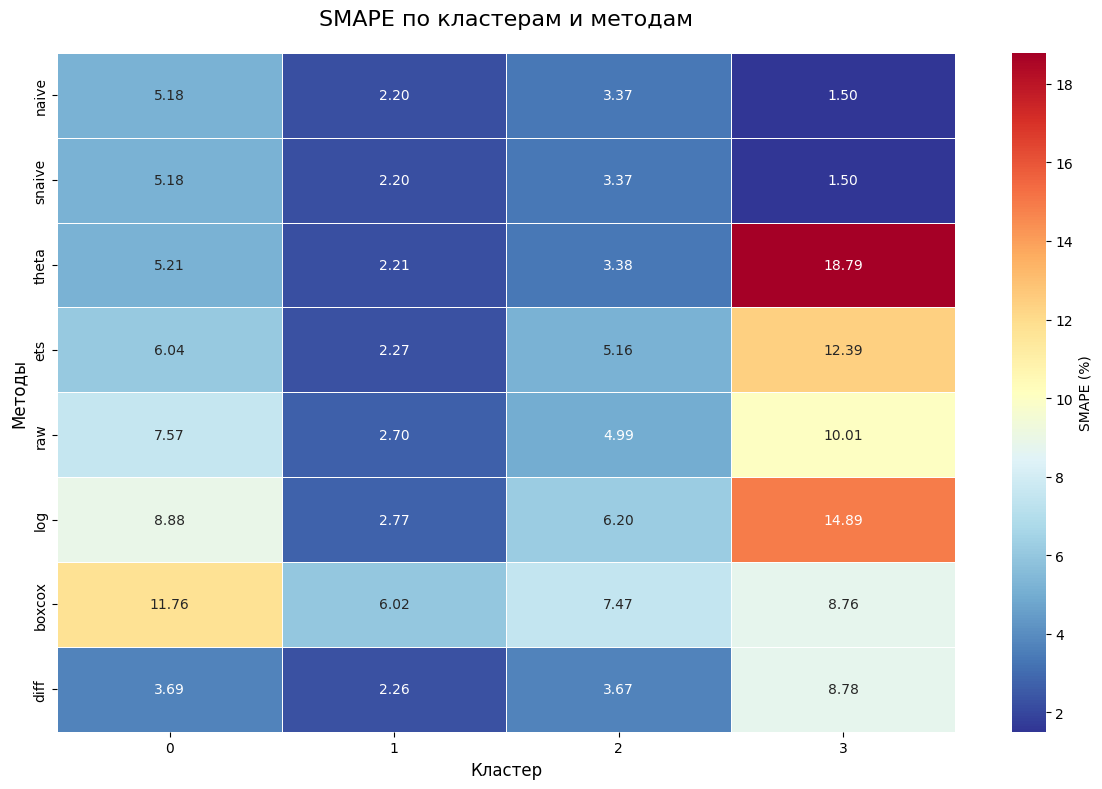

In [13]:

if 'feature_cluster' in results_df.columns:
    cluster_smape_clean = cluster_smape.copy()
    cluster_smape_clean.columns = [col.replace('_SMAPE', '').replace('baseline_', '').replace('catboost_', '')
                                  for col in cluster_smape_clean.columns]

    plt.figure(figsize=(12, 8))
    sns.heatmap(cluster_smape_clean.T, annot=True, fmt='.2f', cmap='RdYlBu_r',
                cbar_kws={'label': 'SMAPE (%)'}, linewidths=0.5)

    plt.title('SMAPE по кластерам и методам', fontsize=16, pad=20)
    plt.xlabel('Кластер', fontsize=12)
    plt.ylabel('Методы', fontsize=12)
    plt.tight_layout()
    plt.show()

C:\Users\dmitr\AppData\Local\Temp\ipykernel_24928\331970098.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot([smape_data[col].dropna() for col in smape_data.columns],


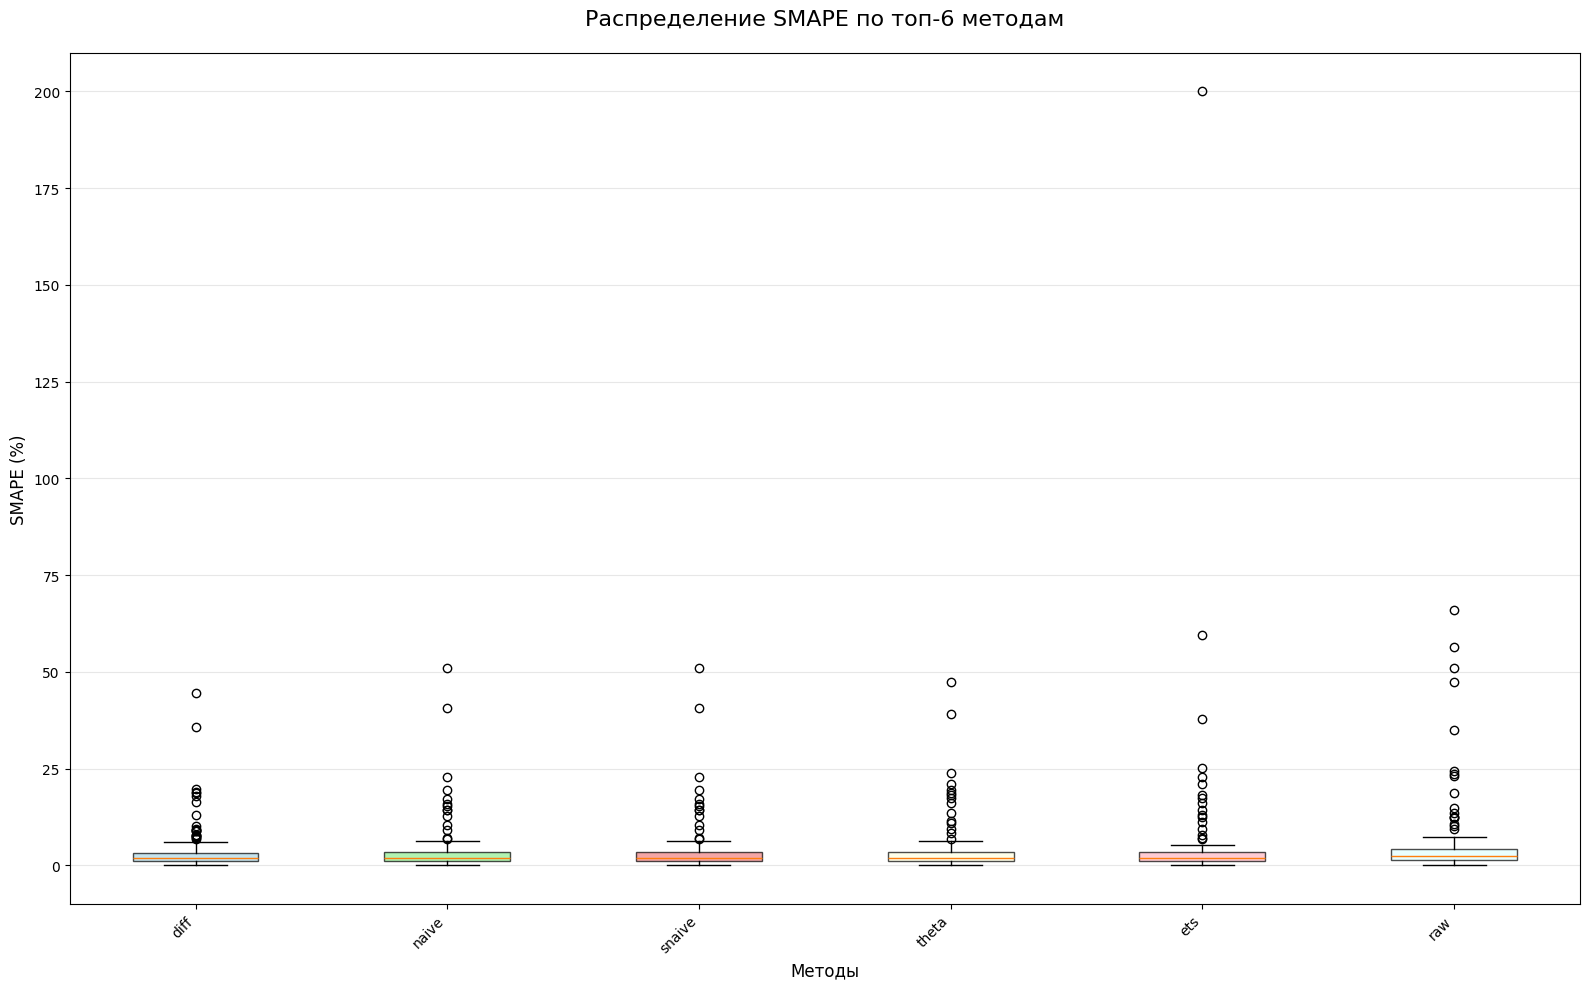

In [14]:
plt.figure(figsize=(16, 10))

top_methods = smape_means.head(6).index
smape_data = results_df[top_methods].copy()

smape_data.columns = [col.replace('_SMAPE', '').replace('baseline_', '').replace('catboost_', '')
                     for col in smape_data.columns]
box = plt.boxplot([smape_data[col].dropna() for col in smape_data.columns],
                  labels=smape_data.columns, patch_artist=True)


colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow', 'lightpink', 'lightcyan']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title('Распределение SMAPE по топ-6 методам', fontsize=16, pad=20)
plt.xlabel('Методы', fontsize=12)
plt.ylabel('SMAPE (%)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

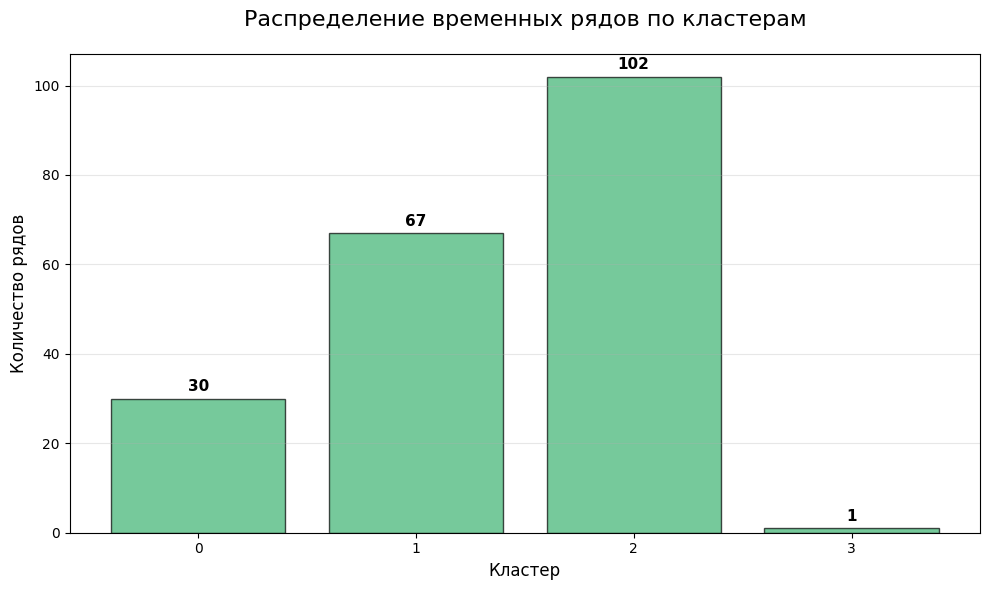

In [15]:
if 'feature_cluster' in results_df.columns:
    cluster_counts = results_df['feature_cluster'].value_counts().sort_index()

    plt.figure(figsize=(10, 6))
    bars = plt.bar(cluster_counts.index.astype(str), cluster_counts.values,
                   color='mediumseagreen', edgecolor='black', alpha=0.7)

    for i, (cluster, count) in enumerate(cluster_counts.items()):
        plt.text(i, count + max(cluster_counts.values) * 0.01, str(count),
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.title('Распределение временных рядов по кластерам', fontsize=16, pad=20)
    plt.xlabel('Кластер', fontsize=12)
    plt.ylabel('Количество рядов', fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

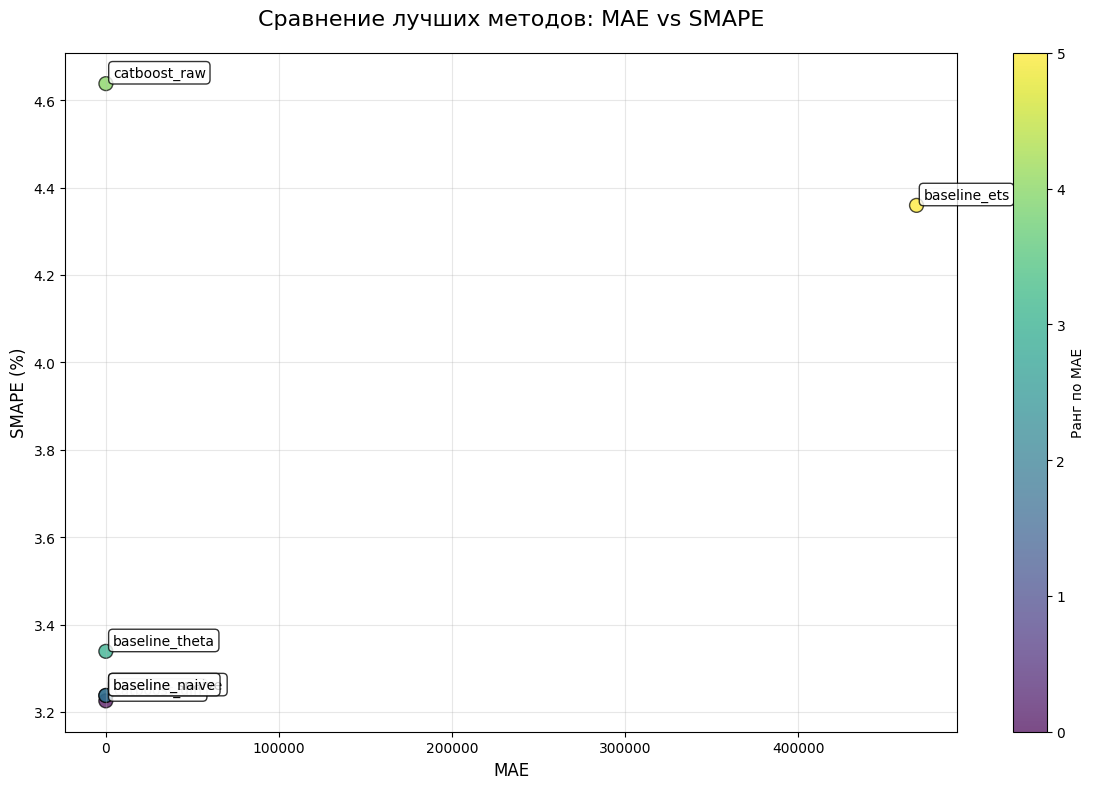

In [18]:
top_methods_mae = mae_means.head(5)
top_methods_smape = smape_means.head(5)

mae_method_names = [name.replace('_MAE', '') for name in top_methods_mae.index]
smape_method_names = [name.replace('_SMAPE', '') for name in top_methods_smape.index]
all_method_names = set(mae_method_names) | set(smape_method_names)

top_data = pd.DataFrame(index=list(all_method_names))
for method in all_method_names:
    mae_key = f'{method}_MAE'
    smape_key = f'{method}_SMAPE'
    if mae_key in mae_means.index:
        top_data.loc[method, 'MAE'] = mae_means[mae_key]
    if smape_key in smape_means.index:
        top_data.loc[method, 'SMAPE'] = smape_means[smape_key]

top_data = top_data.dropna().sort_values('MAE')

plt.figure(figsize=(12, 8))


scatter = plt.scatter(top_data['MAE'], top_data['SMAPE'],
                     s=100, c=range(len(top_data)), cmap='viridis', alpha=0.7, edgecolors='black')


for i, method in enumerate(top_data.index):
    plt.annotate(method, (top_data['MAE'].iloc[i], top_data['SMAPE'].iloc[i]),
                xytext=(5, 5), textcoords='offset points', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.title('Сравнение лучших методов: MAE vs SMAPE', fontsize=16, pad=20)
plt.xlabel('MAE', fontsize=12)
plt.ylabel('SMAPE (%)', fontsize=12)
plt.grid(alpha=0.3)
plt.colorbar(scatter, label='Ранг по MAE')
plt.tight_layout()
plt.show()

## Выводы

1. CatBoost с дифференцированием показывает лучшие результаты
2. Box-Cox трансформация часто дает худшие результаты
3. Разные кластеры требуют разных подходов
4. Простые бейзлайны (naive, seasonal naive) работают хорошо
